In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
os.environ["KAGGLE_API_TOKEN"] = os.getenv("KAGGLE_API_TOKEN")

In [2]:
!kaggle competitions download -c playground-series-s6e3

playground-series-s6e3.zip: Skipping, found more recently modified local copy (use --force to force download)


# importing modules

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [5]:
print("\nDataset Information:")
train.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  str    
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  str    
 4   Dependents        594194 non-null  str    
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  str    
 7   MultipleLines     594194 non-null  str    
 8   InternetService   594194 non-null  str    
 9   OnlineSecurity    594194 non-null  str    
 10  OnlineBackup      594194 non-null  str    
 11  DeviceProtection  594194 non-null  str    
 12  TechSupport       594194 non-null  str    
 13  StreamingTV       594194 non-null  str    
 14  StreamingMovies   594194 non-null  str    
 15  Contract          594194 non-null  str    
 16  Paperless

In [6]:
train.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Get descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
train.describe()


Descriptive Statistics:


,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


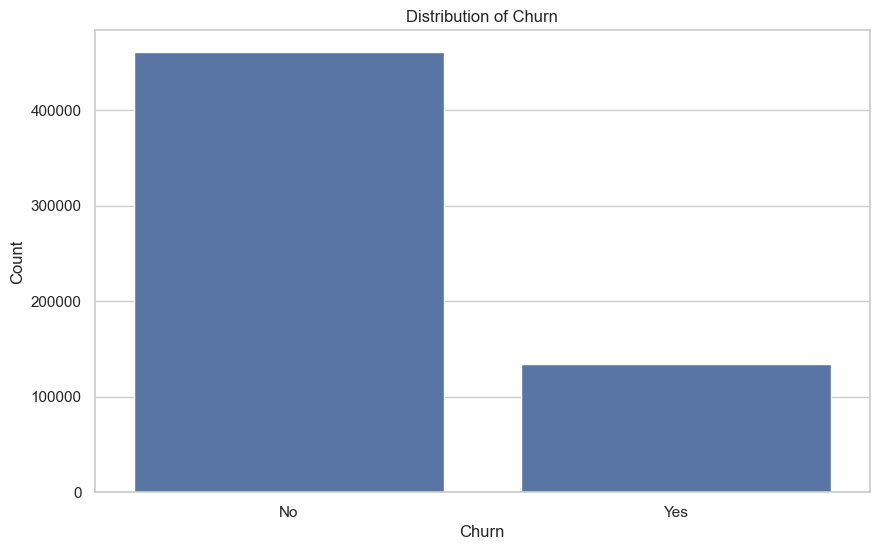

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Churn', data=train)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

* The dataset is not  balanced

In [9]:
numerical_columns=[]
categorical_columns=[]

In [10]:
numerical_columns = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = train.select_dtypes(include=['object','str']).columns.tolist()

In [11]:
categorical_columns.append(numerical_columns.pop(1))

# Univariate analysis

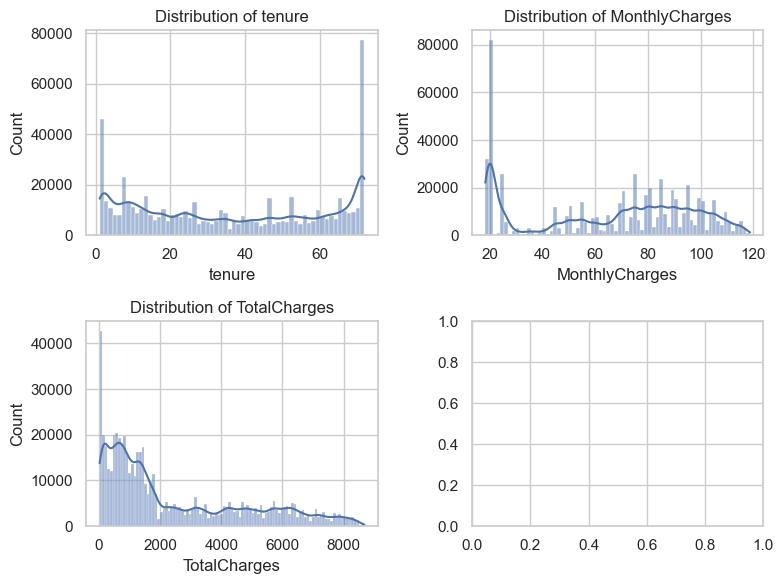

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,6))
for i, col in enumerate(numerical_columns[1:]):
    sns.histplot(train[col], kde=True, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [13]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


# Bivariate analysis of categorical Columns

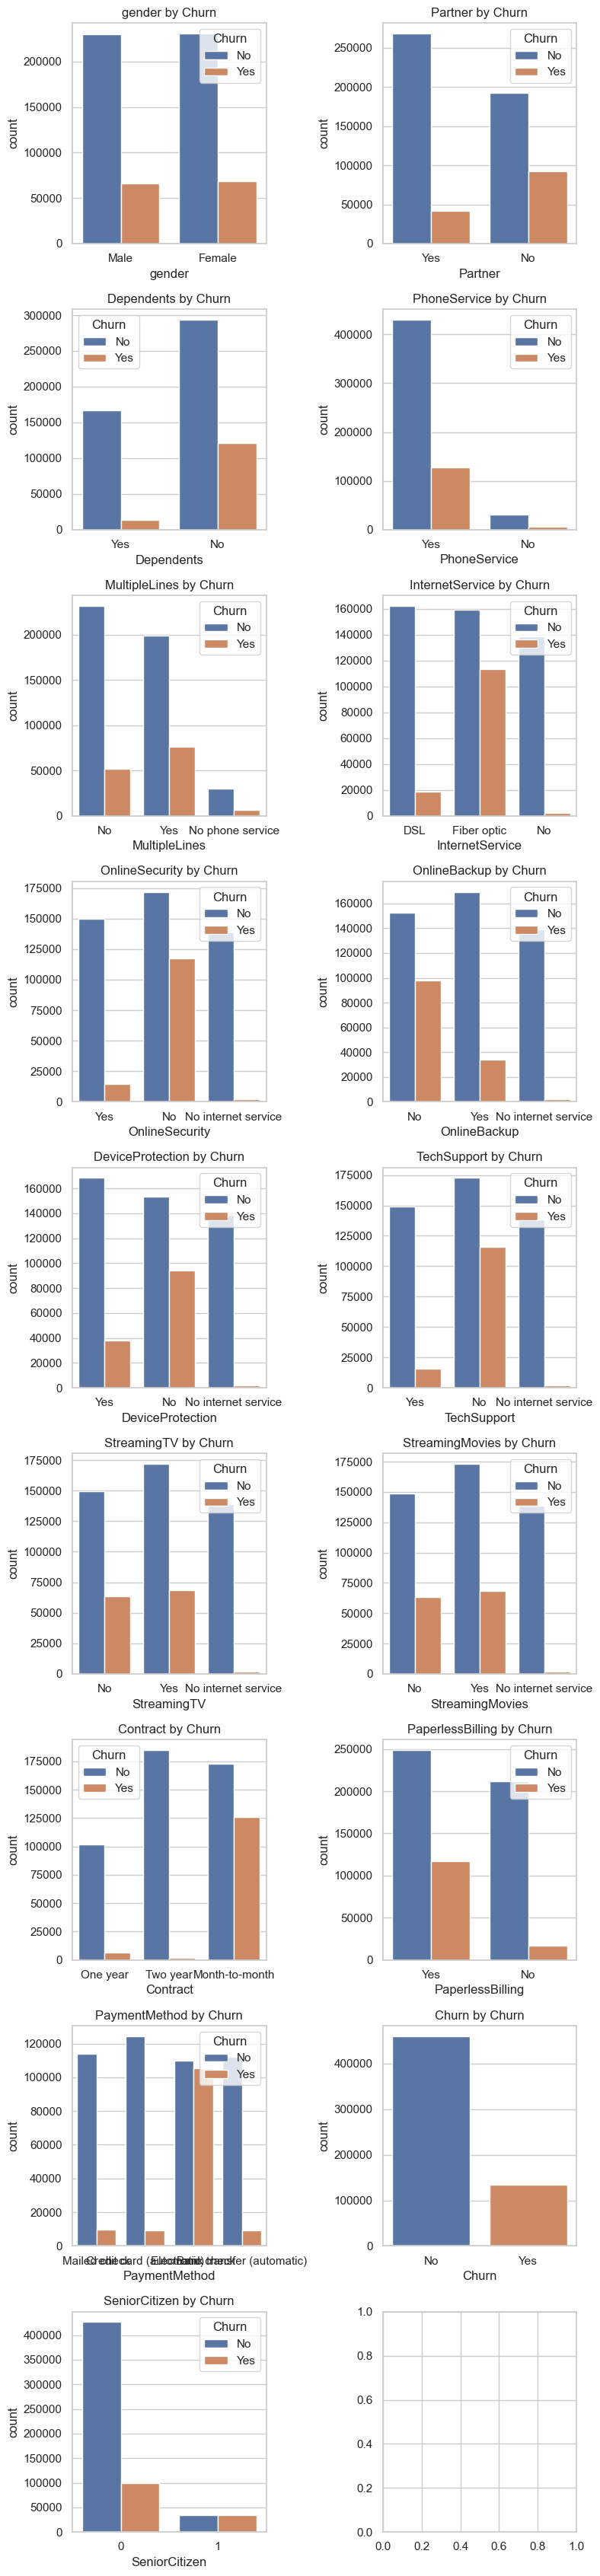

In [24]:
fig, axes = plt.subplots(nrows=len(categorical_columns)//2+1, ncols=2, figsize=(8, 2*len(categorical_columns)))
axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

for i, col in enumerate(categorical_columns):
    sns.countplot(x=col,hue='Churn', data=train, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()

# Bivariate analysis of Numerical Columns

<Figure size 640x480 with 0 Axes>

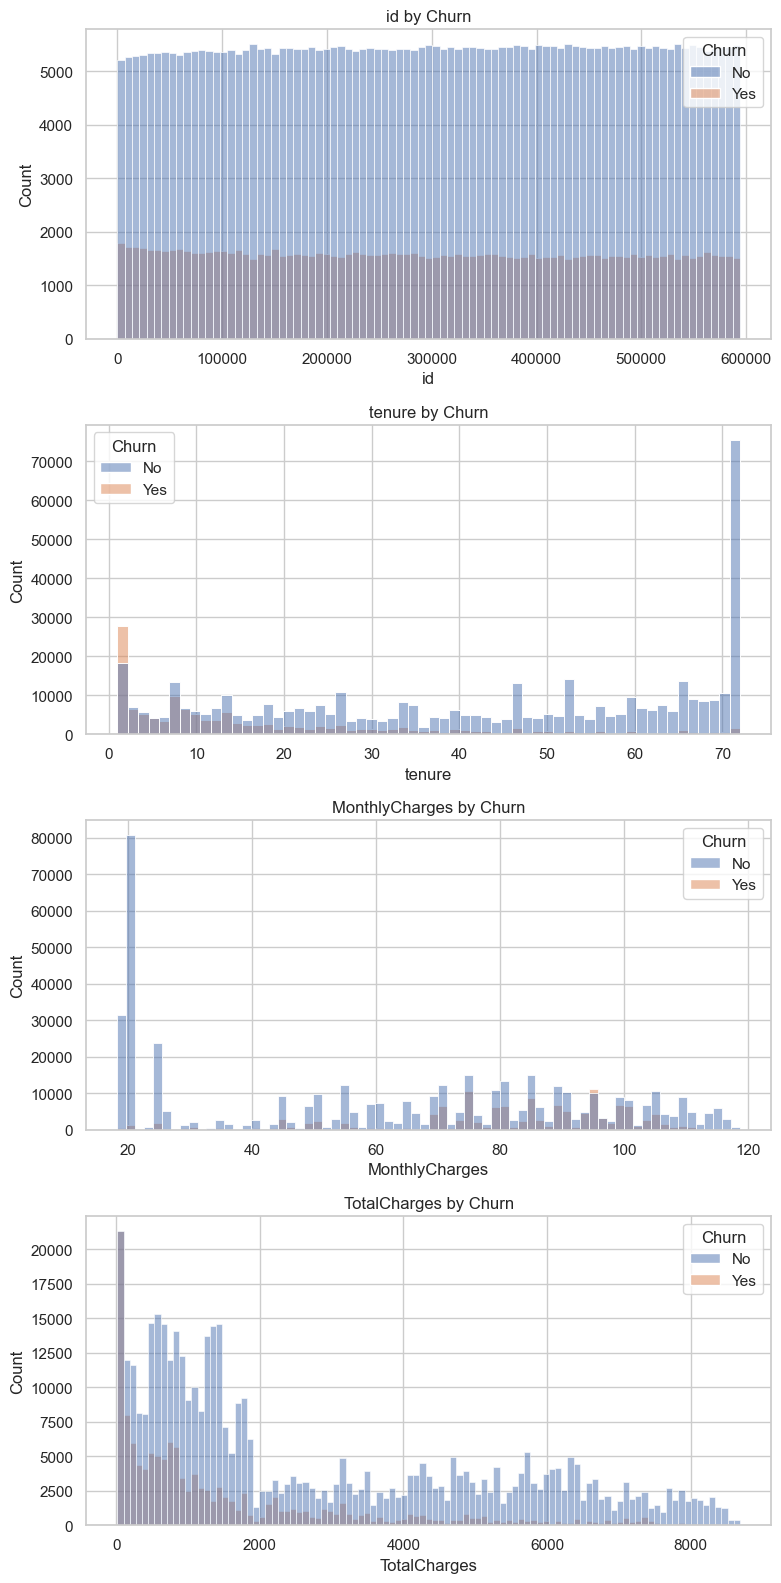

In [16]:
plt.suptitle('Categorical Features by Churn')
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=1, figsize=(8, 4*len(numerical_columns)))
axes = axes.ravel() if isinstance(axes, np.ndarray) else [axes]

for i, col in enumerate(numerical_columns):
    sns.histplot(x=col,hue='Churn', data=train, ax=axes[i])
    axes[i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.show()